# Activity 3 – K-Nearest Neighbors (KNN) Classification
**Dataset:** Seattle Weather | TC2004B — A01286400

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.utils import resample
import warnings; warnings.filterwarnings('ignore')

## 1. Load Data & Class Balance Analysis

In [10]:
df = pd.read_csv('../../../data/s2/seattle-weather.csv').drop(columns=['date'])
X = df.drop(columns=['weather'])
y = df['weather']
counts_before = y.value_counts()
print('Class distribution before balancing:')
print(counts_before)

Class distribution before balancing:
weather
rain       641
sun        640
fog        101
drizzle     53
snow        26
Name: count, dtype: int64


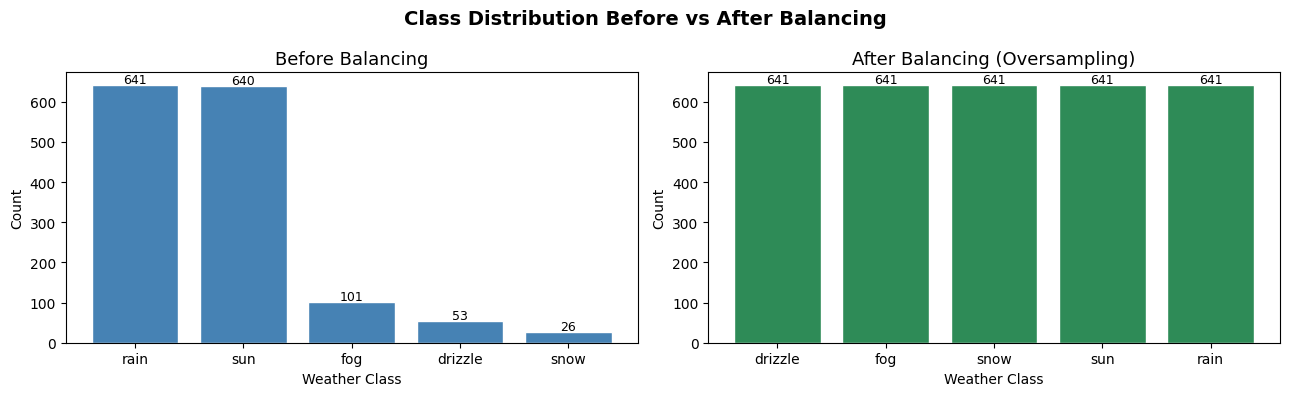

In [11]:
# Oversample minority classes
df_combined = pd.concat([X, y], axis=1)
max_count = counts_before.max()
dfs = [resample(df_combined[df_combined['weather'] == lbl],
               replace=True, n_samples=max_count, random_state=42)
       for lbl in y.unique()]
df_bal = pd.concat(dfs).sample(frac=1, random_state=42).reset_index(drop=True)
X_bal = df_bal.drop('weather', axis=1)
y_bal = df_bal['weather']
counts_after = y_bal.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(counts_before.index, counts_before.values, color='steelblue', edgecolor='white')
axes[0].set_title('Before Balancing', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts_before.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=9)
axes[1].bar(counts_after.index, counts_after.values, color='seagreen', edgecolor='white')
axes[1].set_title('After Balancing (Oversampling)', fontsize=13)
axes[1].set_ylabel('Count')
for i, v in enumerate(counts_after.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=9)
for ax in axes:
    ax.set_xlabel('Weather Class')
plt.suptitle('Class Distribution Before vs After Balancing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_bal, test_size=0.3, random_state=42, stratify=y_bal)
print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]} (70/30 split)')

Train: 2243 | Test: 962 (70/30 split)


## 2. Feature Scaling

KNN relies on distance metrics — features on larger scales would dominate. **StandardScaler** is mandatory.

In [13]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
print('Features scaled with StandardScaler (mean=0, std=1)')
print(f'Feature means (train): {X_train_sc.mean(axis=0).round(3)}')

Features scaled with StandardScaler (mean=0, std=1)
Feature means (train): [-0. -0.  0.  0.]


## 3. KNN Classifier — Manual Hyperparameters

| Parameter | Value | Rationale |
|---|---|---|
| `n_neighbors` | 7 | Odd number avoids ties; slightly more neighbors smooths boundaries |
| `weights` | `'distance'` | Closer neighbors contribute more → better than uniform for non-uniform distributions |
| `metric` | `'minkowski'` | Standard Lp distance family |
| `p` | 2 | Euclidean distance (p=2), suitable for continuous numerical features |

In [14]:
knn = KNeighborsClassifier(
    n_neighbors=7,
    weights='distance',
    metric='minkowski',
    p=2
)
knn.fit(X_train_sc, y_train)
y_pred = knn.predict(X_test_sc)
print('KNN Classification Report:')
print(classification_report(y_test, y_pred))

KNN Classification Report:
              precision    recall  f1-score   support

     drizzle       0.90      1.00      0.95       193
         fog       0.85      0.98      0.91       192
        rain       0.96      0.88      0.92       192
        snow       0.96      1.00      0.98       193
         sun       0.93      0.71      0.81       192

    accuracy                           0.91       962
   macro avg       0.92      0.91      0.91       962
weighted avg       0.92      0.91      0.91       962



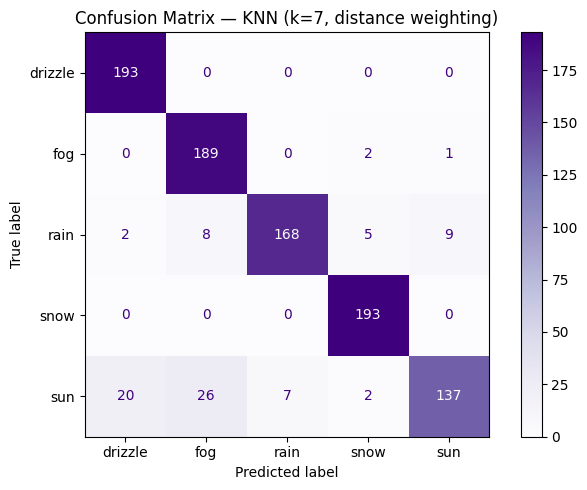

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax, cmap='Purples')
ax.set_title('Confusion Matrix — KNN (k=7, distance weighting)')
plt.tight_layout()
plt.show()

## 4. Effect of k on Accuracy

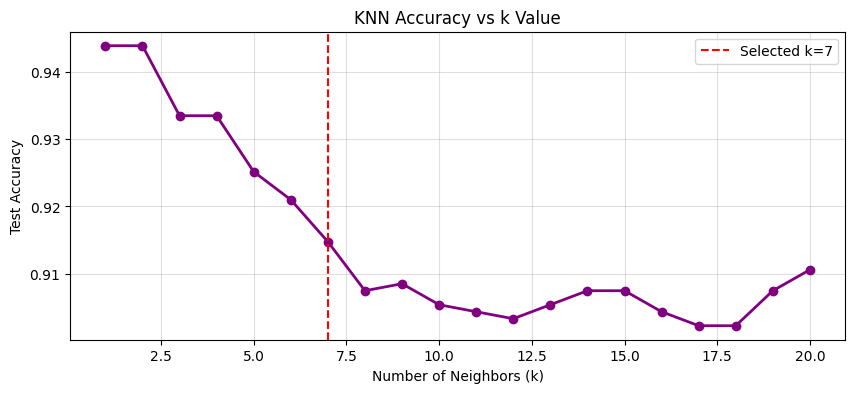

Best k from this range: 1 (accuracy: 0.9439)


In [16]:
k_values = range(1, 21)
accuracies = []
for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='minkowski', p=2)
    knn_k.fit(X_train_sc, y_train)
    accuracies.append(knn_k.score(X_test_sc, y_test))

plt.figure(figsize=(10, 4))
plt.plot(k_values, accuracies, marker='o', color='purple', linewidth=2)
plt.axvline(x=7, color='red', linestyle='--', label='Selected k=7')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Test Accuracy')
plt.title('KNN Accuracy vs k Value')
plt.legend()
plt.grid(alpha=0.4)
plt.show()
best_k = list(k_values)[np.argmax(accuracies)]
print(f'Best k from this range: {best_k} (accuracy: {max(accuracies):.4f})')

## 5. Conclusion

**Hyperparameter impact:**
- **`n_neighbors=7`:** Using k=7 gives a reasonable trade-off between bias and variance. Very small k overfits and very large k underfits.
- **`weights='distance'`:** Nearer neighbors are weighted more heavily. This improves accuracy when classes are not uniformly distributed.
- **`metric='minkowski', p=2` (Euclidean):** Appropriate for continuous numerical features (precipitation, temperature, wind). Euclidean distance captures the geometric proximity of weather measurements naturally.

**Challenges with KNN:**
- Sensitive to scale (hence StandardScaler is essential)
- Computationally expensive at prediction time O(n·d)
- Minority classes may still be misclassified due to sparse neighborhoods even after oversampling